# Wave Period from ARGUS Video F-K Spectra

Estimate peak period ($T_p$) and mean period ($T_{m01}$) from nearshore video
using a dispersion-filtered F-K spectrum, then compare against the 8 m array
in-situ instrument.

**Outline**
1. Load dataset
2. Configuration
3. Explore a single video
4. Exploratory single-timestep F-K analysis
5. Helper functions
6. Full dataset parallel run
7. Video vs in-situ comparison
8. Outlier investigation

## 1. Imports

In [16]:
import gc
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fft
import xarray as xr
import dunex_paths
from IPython.display import HTML
from joblib import Parallel, delayed
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata
from scipy.signal import find_peaks
from scipy.stats import pearsonr

from common.datetime_utils import get_time_resolution_for_date
from utils.video_io import load_frames


## 2. Load Dataset

In [17]:
ds = xr.load_dataset('../combined_dunex_dataset.nc')


## 3. Configuration

In [18]:
ARGUS_PATH = dunex_paths.ARGUS_VIDEO_DIR


## 4. Explore a Single Video

In [ ]:
first_video_path = os.path.join(ARGUS_PATH, ds.source.values[0].replace('_pred', ''))
print(first_video_path)
frames = load_frames(first_video_path)


Frame size: 1600 rows x 500 cols
Analysis windows (6 x 64 px):
  [0] rows 608:672  cols 436:500
  [1] rows 672:736  cols 436:500
  [2] rows 736:800  cols 436:500
  [3] rows 800:864  cols 436:500
  [4] rows 864:928  cols 436:500
  [5] rows 928:992  cols 436:500


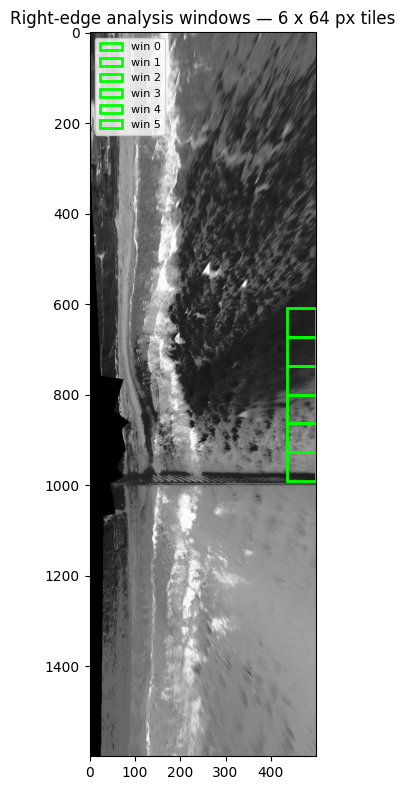

In [20]:
# ── Analysis window layout ───────────────────────────────────────────────────
TILE     = 64    # spatial window size [pixels per side]
N_TILES  = 6     # number of windows stacked vertically at the right-hand edge
N_JOBS   = 4     # parallel workers for the full-dataset run

H_frame, W_frame = frames.shape[1], frames.shape[2]
# Place windows at the right-hand edge, centred vertically
COL_RIGHT = W_frame - TILE
ROW_START = H_frame // 2 - (N_TILES * TILE) // 2
WINDOWS = [(ROW_START + i * TILE, COL_RIGHT) for i in range(N_TILES)]

print(f'Frame size: {H_frame} rows x {W_frame} cols')
print(f'Analysis windows ({N_TILES} x {TILE} px):')
for r, (r0, c0) in enumerate(WINDOWS):
    print(f'  [{r}] rows {r0}:{r0+TILE}  cols {c0}:{c0+TILE}')

# ── Quality-control thresholds ────────────────────────────────────────────────
MISSING_THRESH = 0.05   # max fraction of zero-valued pixels (dead pixels / missing data)
BLUR_THRESH    = 30.0   # min mean Laplacian variance; below this = blurry frame
FROZEN_THRESH  = 2.0    # min mean temporal std; below this = frozen / stuck camera
SAT_THRESH     = 0.10   # max fraction of saturated (255) pixels

# ── Spectral parameters ───────────────────────────────────────────────────────
# Minimum number of wavenumber bins inside the dispersion shell at a given
# frequency.  Frequencies with too few bins are excluded from Tm01 because
# the normalisation Ef / n_k becomes noisy when n_k is very small
# (e.g. only 1-2 bins at low frequencies where the shell is very narrow).
N_K_MIN = 8

# ── Visualise window positions on a reference frame ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(frames[0], cmap='gray', vmin=0, vmax=255)
for i, (r0, c0) in enumerate(WINDOWS):
    rect = Rectangle((c0, r0), TILE, TILE,
                     linewidth=2, edgecolor='lime',
                     facecolor='none', label=f'win {i}')
    ax.add_patch(rect)
ax.legend(loc='upper left', fontsize=8)
ax.set_title(f'Right-edge analysis windows — {N_TILES} x {TILE} px tiles')
plt.tight_layout()


In [21]:
# Preview the first analysis window as an animation
window_row, window_col = WINDOWS[0]
_, fs = get_time_resolution_for_date(pd.Timestamp(ds.time.values[0]).to_pydatetime())

window_frames = frames[:, window_row:window_row+TILE, window_col:window_col+TILE]
print(f'window_frames shape: {window_frames.shape},  fs = {fs} Hz')

n_preview_frames = min(60, len(window_frames))
preview_speedup  = 10   # playback multiplier relative to real time

fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.92)
im_anim = ax.imshow(window_frames[0], cmap='gray', vmin=0, vmax=255, animated=True)
ax.axis('off')
title_text = ax.set_title('t = 0.0 s', fontsize=10)

def _update_frame(i):
    im_anim.set_array(window_frames[i])
    title_text.set_text(f't = {i/fs:.1f} s   (frame {i})')
    return im_anim, title_text

anim = FuncAnimation(fig, _update_frame, frames=n_preview_frames,
                     interval=1000 / fs / preview_speedup, blit=True)
plt.close()
HTML(anim.to_jshtml())


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


window_frames shape: (2397, 64, 64),  fs = 2.0 Hz


## 5. Exploratory: Single-Timestep F-K Spectrum

Manual step-by-step F-K analysis for one video clip.
This shows how the algorithm works before it is packaged into helper functions.

**Algorithm overview:**
1. Compute a Welch-averaged 3-D power spectral density (PSD) in $(f, k_y, k_x)$ space.
2. Keep only the region of the PSD that falls within the surface-gravity-wave dispersion relation $\omega = \sqrt{g k \tanh(kd)}$ for depths $d \in [d_{\min}, d_{\max}]$.
3. Integrate over $(k_y, k_x)$ to get a 1-D frequency spectrum, then find the peak frequency.

1.9176gb allocated
Welch: nperseg=300, n_segs=14  (variance reduced ~14x)
Tp  FK (Welch + depth-range filter): 8.82 s
Tp  instrument (8 m array):           8.71 s


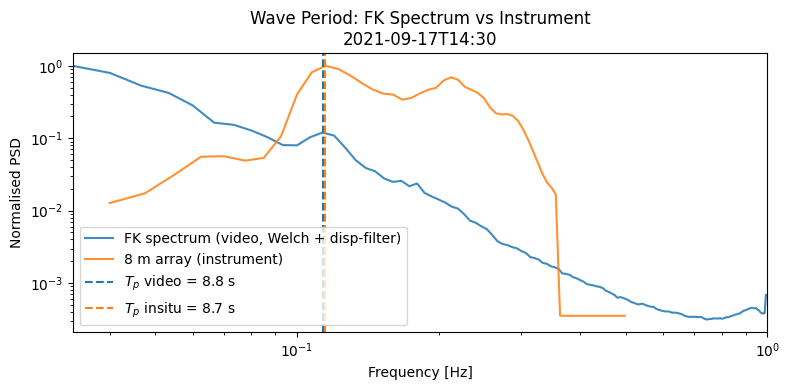

In [22]:
# ── Spectral-analysis parameters ─────────────────────────────────────────────
FRF_OFFSET = 71.8535   # FRF cross-shore axis angle from true north [°]
d_min      = 0.5       # shallowest depth used in dispersion filter [m]
d_max      = 10.0      # deepest depth used in dispersion filter [m]
thickness  = 0.2       # half-bandwidth of the dispersion-relation annulus [rad/s]
dx         = 1.0       # pixel spacing [m/pixel]
nperseg    = 300       # Welch segment length [frames]
time_idx   = 0         # which dataset timestep to analyse

# Load one video clip and fetch its sample rate
video_path = os.path.join(ARGUS_PATH, ds.source.values[time_idx].replace('_pred', ''))
video_clip = load_frames(video_path)
_, fs = get_time_resolution_for_date(
    pd.Timestamp(ds.time.values[time_idx]).to_pydatetime())

# Use the first analysis window only for this exploration
r0, c0 = WINDOWS[0]
video_stack = video_clip[:, r0:r0+TILE, c0:c0+TILE].astype(float)
N_t, N_y, N_x = video_stack.shape

# ── Step 1: Welch-averaged 3-D F-K PSD ───────────────────────────────────────
# Segment the time series into overlapping windows, apply a Hann taper, compute
# the 3-D FFT of each segment, and average the squared magnitudes.
n_overlap    = nperseg // 2
hop_size     = nperseg - n_overlap
hann_window  = np.hanning(nperseg)[:, np.newaxis, np.newaxis]  # broadcast over y, x
win_norm = float((hann_window[:, 0, 0]**2).sum())          # for PSD normalisation

f = np.fft.fftshift(np.fft.fftfreq(nperseg, d=1/fs))   # [Hz], centred on 0
kx        = np.fft.fftshift(np.fft.fftfreq(N_x, d=dx))         # [cycles/m]
ky        = np.fft.fftshift(np.fft.fftfreq(N_y, d=dx))
df, dkx, dky = f[1]-f[0], kx[1]-kx[0], ky[1]-ky[0]

n_welch_segs = (N_t - nperseg) // hop_size + 1
Fwkk_avg = np.zeros((nperseg, N_y, N_x), dtype=np.float64)

for seg_idx in range(n_welch_segs):
    s, e = seg_idx * hop_size, seg_idx * hop_size + nperseg
    seg  = video_stack[s:e] - video_stack[s:e].mean(axis=0)  # remove DC per pixel
    F    = scipy.fft.fftshift(scipy.fft.fftn(seg * hann_window))
    Fwkk_avg += np.abs(F)**2

# Normalise to physical PSD units [px^2 / (Hz * (cycles/m)^2)]
Fwkk_avg /= (n_welch_segs * win_norm * df * dkx * dky)
print(f'Welch: nperseg={nperseg}, n_segs={n_welch_segs}  '
      f'(variance reduced ~{n_welch_segs}x)')

# Keep only positive frequencies; zero the spatial DC component
f_pos = f[nperseg//2:]             # [Hz], f > 0
Fwkk_pos = Fwkk_avg[nperseg//2:].copy()
Fwkk_pos[:, N_y//2, N_x//2] = 0             # remove (f, kx=0, ky=0) DC

# ── Step 2: Dispersion-relation filter ───────────────────────────────────────
# For each 3-D bin (f, ky, kx), check whether the angular frequency omega = 2*pi*f
# is consistent with the linear dispersion relation omega^2 = g*k*tanh(k*d)
# evaluated at depths in [d_min, d_max].  Keep bins inside the resulting annulus.
freq_3d = f_pos[:, np.newaxis, np.newaxis]    # broadcast shape: (Nf, 1, 1)
ky_3d   = ky[np.newaxis, :, np.newaxis]           # (1, Ny, 1)
kx_3d   = kx[np.newaxis, np.newaxis, :]           # (1, 1, Nx)

# Angular wavenumber magnitude [rad/m]
mk_rad = 2 * np.pi * np.sqrt(kx_3d**2 + ky_3d**2)
# Angular frequency of each (f) bin [rad/s]
wi_rad = 2 * np.pi * freq_3d

# Dispersion-curve limits: shallow end (min depth) and deep end (max depth)
wi_shallow = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad * d_min + 1e-10))
wi_deep = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad * d_max + 1e-10))

# Accept bins within `thickness` rad/s of the [wi_shallow, wi_deep] range
disp_mask = (
    (wi_rad >= wi_shallow - thickness) &
    (wi_rad <= wi_deep + thickness)
)
Fwkk_filt = Fwkk_pos * disp_mask
Fwkk_filt[:, N_y//2, N_x//2] = 0   # re-zero DC after masking

# ── Step 3: 1-D frequency spectrum & peak detection ──────────────────────────
# Integrate over (ky, kx) to get E(f).  Normalise by the number of wavenumber
# bins in the dispersion shell to avoid artificially boosting low frequencies
# where the shell is sparse.
n_k      = disp_mask.sum(axis=(1, 2)).clip(min=1)
Ef_filt = Fwkk_filt.sum(axis=(1, 2)) * dkx * dky
Ef_norm_k = Ef_filt / n_k

# Restrict to the 0.033–1.0 Hz swell/wind-wave band
analysis_freq_mask = (f_pos >= 1/30) & (f_pos <= 1.0)

# Find the most prominent spectral peak; fall back to the maximum if no peaks
peak_indices, peak_props = find_peaks(Ef_norm_k[analysis_freq_mask], prominence=0)
if len(peak_indices) > 0:
    dominant_peak_idx = peak_indices[np.argmax(peak_props['prominences'])]
    fp_filt = f_pos[analysis_freq_mask][dominant_peak_idx]
else:
    dominant_peak_idx = int(np.argmax(Ef_norm_k[analysis_freq_mask]))
    fp_filt = f_pos[analysis_freq_mask][dominant_peak_idx]

peak_period_video  = 1.0 / fp_filt
peak_period_insitu = float(ds.waveTp.values[time_idx])

print(f'Tp  FK (Welch + depth-range filter): {peak_period_video:.2f} s')
print(f'Tp  instrument (8 m array):           {peak_period_insitu:.2f} s')

# ── Comparison plot: video FK spectrum vs 8 m array ──────────────────────────
energy_normalized = Ef_norm_k / Ef_norm_k[analysis_freq_mask].max()
insitu_spectrum   = ds.waveEnergyDensity.values[time_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(f_pos[analysis_freq_mask], energy_normalized[analysis_freq_mask],
          label='FK spectrum (video, Welch + disp-filter)', alpha=0.85)
ax.loglog(ds.waveFrequency.values, insitu_spectrum / insitu_spectrum.max(),
          label='8 m array (instrument)', color='C1', alpha=0.85)
ax.axvline(fp_filt,          color='C0', ls='--', lw=1.5,
           label=f'$T_p$ video = {peak_period_video:.1f} s')
ax.axvline(1/peak_period_insitu,  color='C1', ls='--', lw=1.5,
           label=f'$T_p$ insitu = {peak_period_insitu:.1f} s')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Normalised PSD')
ax.set_xlim(1/30, 1.0)
ax.legend()
ax.set_title(f'Wave Period: FK Spectrum vs Instrument\n'
             f'{str(ds.time.values[time_idx])[:16]}')
plt.tight_layout()


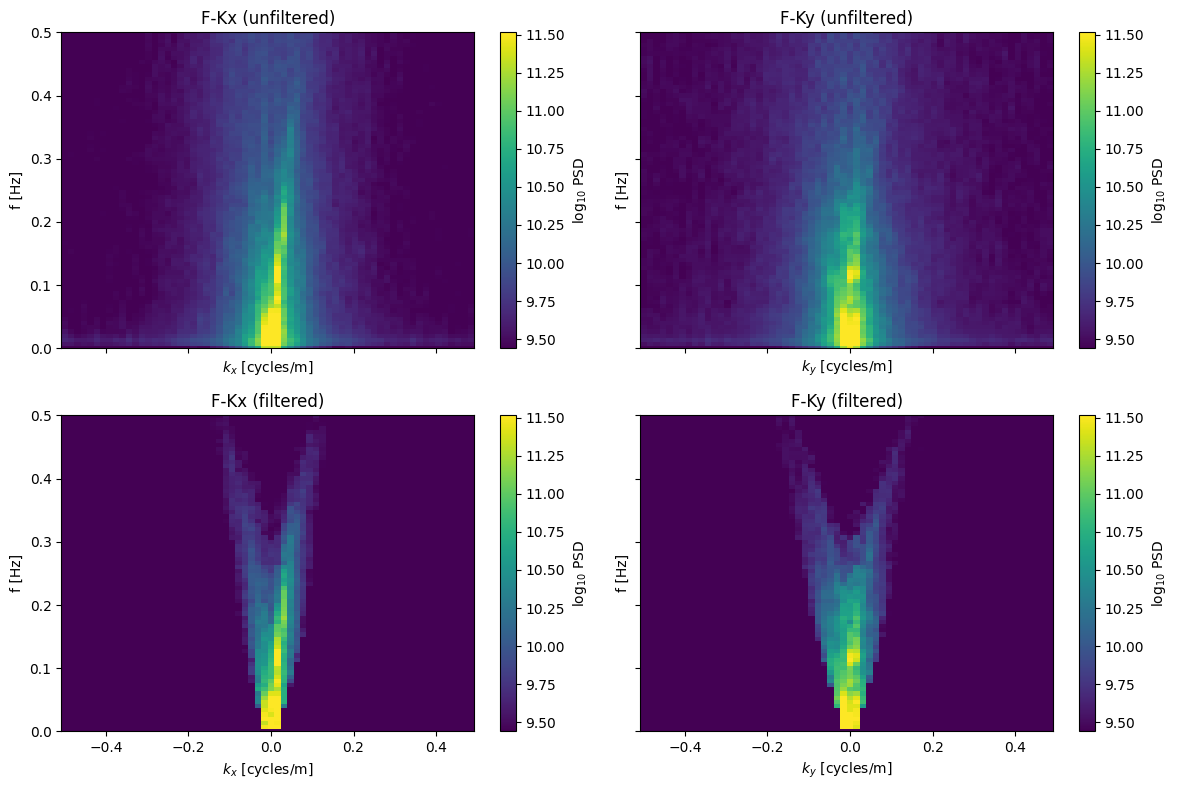

In [23]:
# F-Kx / F-Ky marginals: unfiltered vs. dispersion-filtered, side-by-side
panels = [
    (Fwkk_pos.mean(axis=1),      kx, '$k_x$ [cycles/m]', 'F-Kx (unfiltered)'),
    (Fwkk_pos.mean(axis=2),      ky, '$k_y$ [cycles/m]', 'F-Ky (unfiltered)'),
    (Fwkk_filt.mean(axis=1), kx, '$k_x$ [cycles/m]', 'F-Kx (filtered)'),
    (Fwkk_filt.mean(axis=2), ky, '$k_y$ [cycles/m]', 'F-Ky (filtered)'),
]

log_ref  = np.log10(np.maximum(Fwkk_pos.mean(axis=1), 1e-30))
vmin, vmax = np.percentile(log_ref, [30, 99.5])

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey=True)
for ax, (data, k_axis, k_label, title) in zip(axs.flat, panels):
    log_data = np.log10(np.maximum(data, 1e-30))
    im = ax.pcolormesh(*np.meshgrid(k_axis, f_pos), log_data,
                       shading='nearest', vmin=vmin, vmax=vmax)
    ax.set_xlabel(k_label)
    ax.set_ylabel('f [Hz]')
    ax.set_ylim(0, 0.5)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='log$_{10}$ PSD')
plt.tight_layout()



Quantity                              Video FK Insitu 8m
Tp [s]                                    8.82      8.71
fp [Hz]                                 0.1133    0.1148
Peak direction [deg from N, CW]           71.9     105.0
Mean direction [deg from N, CW]           76.7      93.5


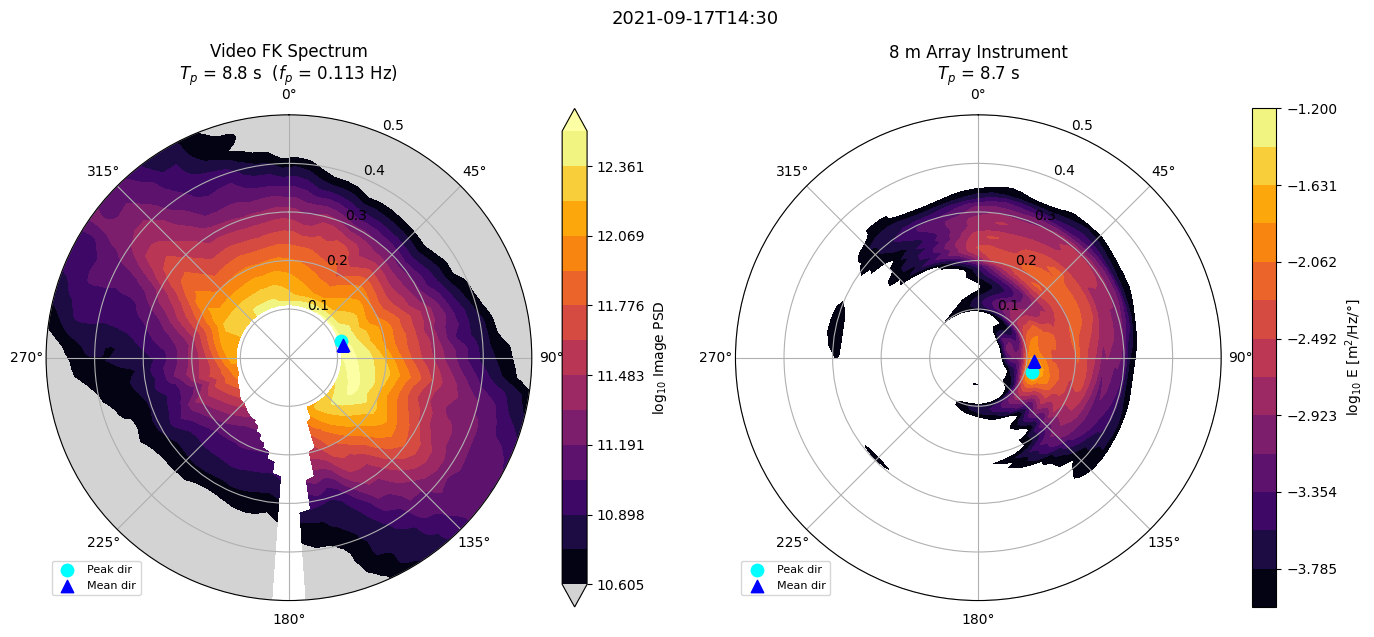

In [24]:
# ── Directional (f, θ) spectrum mapped from the filtered (f, ky, kx) PSD ────
# Sum over time to get a 2-D spatial PSD, then map each (ky, kx) bin to a
# (frequency, direction) coordinate using the dispersion relation.
Fkk_filt = Fwkk_filt.sum(axis=0)   # (N_y, N_x)

X, Y  = np.meshgrid(kx, ky)
k_mag = np.sqrt(X**2 + Y**2)                         # wavenumber magnitude [cycles/m]
k_rad = 2 * np.pi * k_mag                            # angular wavenumber [rad/m]

# Map wavenumber magnitude to frequency via dispersion at a reference depth
d_mid    = 0.5 * (d_min + d_max)
f_from_k = np.sqrt(9.81 * k_rad * np.tanh(k_rad * d_mid + 1e-10)) / (2 * np.pi)

# Convert wavenumber direction to oceanographic convention (degrees from N, CW)
# theta = 0 → waves coming from the north; FRF_OFFSET rotates to local coordinates
theta_rad = np.deg2rad(FRF_OFFSET + 90) - np.arctan2(X, Y)
theta_rad = (theta_rad + np.pi) % (2 * np.pi) - np.pi

# Jacobian: E(f, theta) = |k| * E(ky, kx)
Fft = k_mag * Fkk_filt

# Interpolate onto a regular (f, θ) grid
valid_k    = k_mag > 0.01
f_grid     = np.linspace(1/30, 0.5, 100)
theta_grid = np.linspace(-np.pi, np.pi, 90)
TH, FR     = np.meshgrid(theta_grid, f_grid)

Fft_interp = griddata(
    (theta_rad[valid_k].ravel(), f_from_k[valid_k].ravel()),
    np.log10(np.maximum(Fft[valid_k].ravel(), 1e-30)),
    (TH, FR), method='linear', fill_value=np.nan,
)

# Close the polar plot (repeat first column at theta + 2π)
theta_grid_closed   = np.append(theta_grid, theta_grid[0] + 2*np.pi)
Fft_interp_closed     = np.concatenate([Fft_interp, Fft_interp[:, :1]], axis=1)
TH_closed, FR_closed = np.meshgrid(theta_grid_closed, f_grid)

# ── Peak and mean wave direction from the video FK spectrum ──────────────────
# Locate the spatial-PSD peak at the dominant frequency
freq_mask_indices  = np.where(analysis_freq_mask)[0]
peak_freq_global_idx = (
    freq_mask_indices[dominant_peak_idx]
    if len(peak_indices) > 0
    else int(np.argmax(Ef_norm_k[analysis_freq_mask])) + np.sum(~analysis_freq_mask)
)
spatial_psd_at_peak_freq = Fwkk_filt[peak_freq_global_idx]

peak_wavenumber_idx = np.unravel_index(
    np.argmax(spatial_psd_at_peak_freq), spatial_psd_at_peak_freq.shape)
peak_dir_deg = np.degrees(theta_rad[peak_wavenumber_idx]) % 360
peak_dir_rad = np.radians(peak_dir_deg)

# Energy-weighted mean direction
psd_flat   = spatial_psd_at_peak_freq.ravel()
theta_flat = theta_rad.ravel()
mean_dir_deg = np.degrees(
    np.arctan2(np.dot(psd_flat, np.sin(theta_flat)),
               np.dot(psd_flat, np.cos(theta_flat)))
) % 360
mean_dir_rad = np.radians(mean_dir_deg)

# ── Side-by-side polar plots: video vs instrument ─────────────────────────────
spec_cmap = plt.cm.inferno.copy()
spec_cmap.set_under('lightgrey')

fig, axs = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})

# --- Video directional spectrum ---
vmin_p = np.nanpercentile(Fft_interp, 20)
vmax_p = np.nanpercentile(Fft_interp, 99)
ax = axs[0]
ax.set_theta_direction(-1); ax.set_theta_zero_location('N')
im0 = ax.contourf(TH_closed, FR_closed, Fft_interp_closed,
                  cmap=spec_cmap, levels=np.linspace(vmin_p, vmax_p, 14), extend='both')
plt.colorbar(im0, ax=ax, label='log$_{10}$ Image PSD')
ax.scatter(peak_dir_rad, fp_filt, color='cyan', s=80, zorder=5, label='Peak dir')
ax.scatter(mean_dir_rad, fp_filt, color='blue', s=80, zorder=5,
           marker='^', label='Mean dir')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0, 0.5)
ax.set_title(f'Video FK Spectrum\n$T_p$ = {peak_period_video:.1f} s  '
             f'($f_p$ = {fp_filt:.3f} Hz)')

# --- 8 m array instrument directional spectrum ---
dirs_rad        = np.radians(ds.waveDirectionBins.values)
insitu_freqs    = ds.waveFrequency.values
dir_spec        = ds.directionalWaveEnergyDensity.values[time_idx]   # (freq, dir)
dirs_rad_closed = np.append(dirs_rad, dirs_rad[0] + 2*np.pi)
dir_spec_closed = np.concatenate([dir_spec, dir_spec[:, :1]], axis=1)
TH_inst, FR_inst = np.meshgrid(dirs_rad_closed, insitu_freqs)

peak_dir_insitu = float(ds.wavePeakDirectionPeakFrequency.values[time_idx])
mean_dir_insitu = float(ds.waveMeanDirectionPeakFrequency.values[time_idx])
peak_freq_insitu = 1.0 / peak_period_insitu

ax = axs[1]
ax.set_theta_direction(-1); ax.set_theta_zero_location('N')
im1 = ax.contourf(TH_inst, FR_inst,
                  np.log10(np.maximum(dir_spec_closed, 1e-10)),
                  cmap=spec_cmap, levels=np.linspace(-4, -1.2, 14))
plt.colorbar(im1, ax=ax, label='log$_{10}$ E [m$^2$/Hz/°]')
ax.scatter(np.radians(peak_dir_insitu), peak_freq_insitu,
           color='cyan', s=80, zorder=5, label='Peak dir')
ax.scatter(np.radians(mean_dir_insitu), peak_freq_insitu,
           color='blue', s=80, zorder=5, marker='^', label='Mean dir')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0, 0.5)
ax.set_title(f'8 m Array Instrument\n$T_p$ = {peak_period_insitu:.1f} s')

plt.suptitle(f'{str(ds.time.values[time_idx])[:16]}', y=1.02, fontsize=13)
plt.tight_layout()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'':=<56}")
print(f"{'Quantity':<36} {'Video FK':>9} {'Insitu 8m':>9}")
print(f"{'':=<56}")
print(f"{'Tp [s]':<36} {peak_period_video:>9.2f} {peak_period_insitu:>9.2f}")
print(f"{'fp [Hz]':<36} {fp_filt:>9.4f} {peak_freq_insitu:>9.4f}")
print(f"{'Peak direction [deg from N, CW]':<36} {peak_dir_deg:>9.1f} {peak_dir_insitu:>9.1f}")
print(f"{'Mean direction [deg from N, CW]':<36} {mean_dir_deg:>9.1f} {mean_dir_insitu:>9.1f}")
print(f"{'':=<56}")


## 6. Helper Functions

These functions are used by the single-timestep diagnostic plots (cell 14)
and defined here for reuse.  The parallel worker (cell below) contains
inline copies for pickling compatibility with `joblib`.

In [26]:
def window_quality_check(crop, missing_thresh, blur_thresh, frozen_thresh, sat_thresh):
    """
    Quality-check a single window crop (N_t, H, W) against four failure modes.
    Returns (passed: bool, description: str).
    """
    # --- Missing data: too many zero-valued pixels ---
    missing_fraction = float((crop == 0).mean())
    if missing_fraction > missing_thresh:
        return False, f'missing fraction={missing_fraction:.2f}'

    # --- Blurry: Laplacian variance measures image sharpness ---
    subsampled_frames = crop[::20].astype(np.float32)  # sub-sample for speed
    sharpness = float(np.mean(
        [cv2.Laplacian(frame, cv2.CV_32F).var() for frame in subsampled_frames]))
    if sharpness < blur_thresh:
        return False, f'blur sharpness={sharpness:.1f}'

    # --- Frozen: no temporal variation (stuck camera or dead channel) ---
    temporal_variability = float(crop.std(axis=0).mean())
    if temporal_variability < frozen_thresh:
        return False, f'frozen variability={temporal_variability:.2f}'

    # --- Saturated: too many maxed-out pixels ---
    saturation_fraction = float((crop == 255).mean())
    if saturation_fraction > sat_thresh:
        return False, f'saturated fraction={saturation_fraction:.2f}'

    return True, f'ok sharpness={sharpness:.1f} variability={temporal_variability:.2f}'


def compute_dispersion_filtered_spectrum(crop, fs, dx, nperseg, d_min, d_max, thickness):
    """
    Compute a Welch-averaged, dispersion-filtered 1-D frequency spectrum
    from a (N_t, H, W) pixel intensity crop.

    Returns
    -------
    f_pos      : 1-D array of positive frequencies [Hz]
    Ef_filt : integrated energy per frequency bin
    Ef_norm_k : energy normalised by number of k-bins in the dispersion shell
    n_k        : number of wavenumber bins inside the dispersion shell per frequency
    """
    video_stack = crop.astype(np.float32)
    N_t, N_y, N_x = video_stack.shape

    n_overlap    = nperseg // 2
    hop_size     = nperseg - n_overlap
    hann_window  = np.hanning(nperseg)[:, np.newaxis, np.newaxis].astype(np.float32)
    win_norm = float((hann_window[:, 0, 0]**2).sum())

    f = np.fft.fftshift(np.fft.fftfreq(nperseg, d=1/fs))
    kx        = np.fft.fftshift(np.fft.fftfreq(N_x, d=dx))
    ky        = np.fft.fftshift(np.fft.fftfreq(N_y, d=dx))
    df, dkx, dky = f[1]-f[0], kx[1]-kx[0], ky[1]-ky[0]

    n_welch_segs = (N_t - nperseg) // hop_size + 1
    Fwkk_avg = np.zeros((nperseg, N_y, N_x), dtype=np.float64)
    for seg_idx in range(n_welch_segs):
        s, e = seg_idx * hop_size, seg_idx * hop_size + nperseg
        seg  = video_stack[s:e] - video_stack[s:e].mean(axis=0)
        Fwkk_avg += np.abs(scipy.fft.fftshift(scipy.fft.fftn(seg * hann_window)))**2
        gc.collect()
    del video_stack, hann_window
    gc.collect()
    Fwkk_avg /= (n_welch_segs * win_norm * df * dkx * dky)

    f_pos  = f[nperseg//2:]
    Fwkk_pos = Fwkk_avg[nperseg//2:].copy()
    del Fwkk_avg
    gc.collect()
    Fwkk_pos[:, N_y//2, N_x//2] = 0   # zero spatial DC

    # Dispersion-relation filter
    freq_3d         = f_pos[:, np.newaxis, np.newaxis]
    ky_3d           = ky[np.newaxis, :, np.newaxis]
    kx_3d           = kx[np.newaxis, np.newaxis, :]
    mk_rad       = 2 * np.pi * np.sqrt(kx_3d**2 + ky_3d**2)
    wi_rad        = 2 * np.pi * freq_3d
    wi_shallow = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad * d_min + 1e-10))
    wi_deep = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad * d_max + 1e-10))
    disp_mask = (
        (wi_rad >= wi_shallow - thickness) &
        (wi_rad <= wi_deep + thickness)
    )
    del freq_3d, ky_3d, kx_3d, mk_rad, wi_rad, wi_shallow, wi_deep
    gc.collect()

    Fwkk_filt = Fwkk_pos * disp_mask
    Fwkk_filt[:, N_y//2, N_x//2] = 0
    del Fwkk_pos
    gc.collect()

    n_k         = disp_mask.sum(axis=(1, 2))
    Ef_filt = Fwkk_filt.sum(axis=(1, 2)) * dkx * dky
    Ef_norm_k = Ef_filt / n_k.clip(min=1)
    del Fwkk_filt, disp_mask
    gc.collect()

    return f_pos, Ef_filt, Ef_norm_k, n_k


print('Helper functions defined: window_quality_check, compute_dispersion_filtered_spectrum')


Helper functions defined: window_quality_check, compute_dispersion_filtered_spectrum


## 7. Full Dataset: Parallel F-K Analysis

Process every timestep in the dataset.  Each worker redefines the QC and
spectral functions locally to avoid pickling issues with `joblib/loky`.

In [27]:
N_JOBS = 4


def _process_timestep(source, time_val, argus_path,
                      windows, tile,
                      frf_offset, d_min, d_max, thickness, dx, nperseg,
                      missing_thresh, blur_thresh, frozen_thresh, sat_thresh,
                      n_k_min):
    """
    Load one ARGUS video, run multi-window QC and F-K spectral analysis,
    and return peak and mean wave period estimates.

    All helper functions are defined inline so joblib/loky can pickle them
    without needing access to the notebook namespace.
    """
    import gc
    import os

    import cv2
    import numpy as np
    import pandas as pd
    import scipy.fft
    from scipy.signal import find_peaks

    from common.datetime_utils import get_time_resolution_for_date
    from utils.video_io import load_frames

    # ── Inline QC check (mirrors window_quality_check above) ─────────────────
    def _check_window_quality(crop):
        missing_fraction = float((crop == 0).mean())
        if missing_fraction > missing_thresh:
            return False, f'missing fraction={missing_fraction:.2f}'
        subsampled_frames = crop[::20].astype(np.float32)
        sharpness = float(np.mean(
            [cv2.Laplacian(f, cv2.CV_32F).var() for f in subsampled_frames]))
        if sharpness < blur_thresh:
            return False, f'blur sharpness={sharpness:.1f}'
        temporal_variability = float(crop.std(axis=0).mean())
        if temporal_variability < frozen_thresh:
            return False, f'frozen variability={temporal_variability:.2f}'
        saturation_fraction = float((crop == 255).mean())
        if saturation_fraction > sat_thresh:
            return False, f'saturated fraction={saturation_fraction:.2f}'
        return True, f'ok sharpness={sharpness:.1f} variability={temporal_variability:.2f}'

    # ── Inline FK spectrum (mirrors compute_dispersion_filtered_spectrum above) ─
    def _compute_spectrum(crop, fs):
        video_stack = crop.astype(np.float32)
        N_t, N_y, N_x = video_stack.shape
        n_overlap    = nperseg // 2
        hann_window  = np.hanning(nperseg)[:, np.newaxis, np.newaxis].astype(np.float32)
        win_norm = float((hann_window[:, 0, 0]**2).sum())
        f = np.fft.fftshift(np.fft.fftfreq(nperseg, d=1/fs))
        kx = np.fft.fftshift(np.fft.fftfreq(N_x, d=dx))
        ky = np.fft.fftshift(np.fft.fftfreq(N_y, d=dx))
        df, dkx, dky = f[1]-f[0], kx[1]-kx[0], ky[1]-ky[0]
        n_welch_segs = (N_t - nperseg) // (nperseg - n_overlap) + 1
        Fwkk_avg = np.zeros((nperseg, N_y, N_x), dtype=np.float64)
        for seg_idx in range(n_welch_segs):
            s, e = seg_idx * (nperseg - n_overlap), seg_idx * (nperseg - n_overlap) + nperseg
            seg  = video_stack[s:e] - video_stack[s:e].mean(axis=0)
            Fwkk_avg += np.abs(
                scipy.fft.fftshift(scipy.fft.fftn(seg * hann_window)))**2
            gc.collect()
        del video_stack, hann_window
        gc.collect()
        Fwkk_avg /= (n_welch_segs * win_norm * df * dkx * dky)
        f_pos  = f[nperseg//2:]
        Fwkk_pos = Fwkk_avg[nperseg//2:].copy()
        del Fwkk_avg
        gc.collect()
        Fwkk_pos[:, N_y//2, N_x//2] = 0
        freq_3d         = f_pos[:, np.newaxis, np.newaxis]
        ky_3d           = ky[np.newaxis, :, np.newaxis]
        kx_3d           = kx[np.newaxis, np.newaxis, :]
        mk_rad       = 2*np.pi*np.sqrt(kx_3d**2 + ky_3d**2)
        wi_rad        = 2*np.pi*freq_3d
        wi_shallow = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad*d_min + 1e-10))
        wi_deep = np.sqrt(9.81 * mk_rad * np.tanh(mk_rad*d_max + 1e-10))
        disp_mask = (
            (wi_rad >= wi_shallow - thickness) &
            (wi_rad <= wi_deep + thickness)
        )
        del freq_3d, ky_3d, kx_3d, mk_rad, wi_rad, wi_shallow, wi_deep
        gc.collect()
        Fwkk_filt = Fwkk_pos * disp_mask
        Fwkk_filt[:, N_y//2, N_x//2] = 0
        del Fwkk_pos
        gc.collect()
        n_k         = disp_mask.sum(axis=(1, 2))
        Ef_filt = Fwkk_filt.sum(axis=(1, 2)) * dkx * dky
        Ef_norm_k = Ef_filt / n_k.clip(min=1)
        del Fwkk_filt, disp_mask
        gc.collect()
        return f_pos, Ef_filt, Ef_norm_k, n_k

    # ── Load video ────────────────────────────────────────────────────────────
    video_path = os.path.join(argus_path, source.replace('_pred', ''))
    if not os.path.exists(video_path):
        return None

    frames = load_frames(video_path)
    _, fs  = get_time_resolution_for_date(pd.Timestamp(time_val).to_pydatetime())

    # ── Run QC + spectrum on each analysis window ─────────────────────────────
    window_spectra     = []   # Ef_norm_k from each good window
    window_kbin_counts = []   # n_k from each good window
    qc_log             = []

    for r0, c0 in windows:
        crop = frames[:, r0:r0+tile, c0:c0+tile].copy()
        passed, tag = _check_window_quality(crop)
        qc_log.append(tag)
        if not passed:
            del crop
            gc.collect()
            continue
        try:
            f_pos, _, Ef_norm_k, n_k = _compute_spectrum(crop, fs)
            window_spectra.append(Ef_norm_k)
            window_kbin_counts.append(n_k)
        except Exception as e:
            qc_log[-1] += f' [fk error: {e}]'
        del crop
        gc.collect()

    del frames
    gc.collect()

    if not window_spectra:
        return None

    # ── Average spectra across good windows ───────────────────────────────────
    Ef_nk_mean  = np.mean(window_spectra, axis=0)
    n_k_mean   = np.mean(window_kbin_counts, axis=0)

    # Restrict to 0.033–1.0 Hz wave band
    analysis_freq_mask = (f_pos >= 1/30) & (f_pos <= 1.0)

    # Exclude low-frequency bins with too few k-bins in the dispersion shell
    # (n_k is very small there, making Ef_norm_k unreliable)
    reliable_freq_mask = analysis_freq_mask & (n_k_mean >= n_k_min)
    if reliable_freq_mask.sum() < 3:
        reliable_freq_mask = analysis_freq_mask   # fallback: use full band

    # ── Mean frequency (Tm01) ─────────────────────────────────────────────────
    ef_band   = Ef_nk_mean[reliable_freq_mask]
    ef_sum  = ef_band.sum()
    fm_filt  = (
        float((f_pos[reliable_freq_mask] * ef_band).sum() / ef_sum)
        if ef_sum > 0 else float(f_pos[analysis_freq_mask].mean())
    )

    # ── Peak frequency (Tp) ───────────────────────────────────────────────────
    peak_indices, peak_props = find_peaks(
        Ef_nk_mean[analysis_freq_mask], prominence=0)
    if len(peak_indices) > 0:
        dominant_peak_idx = peak_indices[np.argmax(peak_props['prominences'])]
        fp_filt = float(f_pos[analysis_freq_mask][dominant_peak_idx])
    else:
        fp_filt = float(
            f_pos[analysis_freq_mask][np.argmax(Ef_nk_mean[analysis_freq_mask])])

    return {
        'Tp': 1.0/fp_filt,  'fp': fp_filt,
        'Tm': 1.0/fm_filt,  'fm': fm_filt,
        'n_good': len(window_spectra),
        'qc_log': qc_log,
    }


# ── Run all timesteps in parallel ─────────────────────────────────────────────
raw_results = Parallel(n_jobs=N_JOBS, verbose=5, backend='loky')(
    delayed(_process_timestep)(
        ds.source.values[i], ds.time.values[i], ARGUS_PATH,
        WINDOWS, TILE,
        FRF_OFFSET, d_min, d_max, thickness, dx, nperseg,
        MISSING_THRESH, BLUR_THRESH, FROZEN_THRESH, SAT_THRESH,
        N_K_MIN,
    )
    for i in range(len(ds.time))
)

# ── Collect valid results ─────────────────────────────────────────────────────
success_mask = [r is not None for r in raw_results]
results      = [r for r in raw_results if r is not None]
time_val     = ds.time.values[success_mask]
print(f'{sum(success_mask)}/{len(success_mask)} timesteps succeeded')
for i, r in enumerate(results):
    print(f'  [{i}] n_good={r["n_good"]}/{len(WINDOWS)}  '
          f'Tp={r["Tp"]:.1f}s  Tm={r["Tm"]:.1f}s  '
          + '  '.join(r['qc_log']))

# ── Extract time series ───────────────────────────────────────────────────────
Tp_vid = np.array([r['Tp'] for r in results])
fp_vid = np.array([r['fp'] for r in results])
Tm_vid = np.array([r['Tm'] for r in results])
fm_vid = np.array([r['fm'] for r in results])

# ── In-situ instrument values (matched to valid timesteps) ────────────────────
Tp_ins = ds.waveTp.values[success_mask]
fp_ins = 1.0 / Tp_ins
pd_ins = ds.wavePeakDirectionPeakFrequency.values[success_mask]
md_ins = ds.waveMeanDirectionPeakFrequency.values[success_mask]

# ── In-situ mean period Tm01 from the spectral energy density ────────────────
insitu_freqs    = ds.waveFrequency.values
insitu_energy_all = ds.waveEnergyDensity.values[success_mask]
insitu_freq_mask  = (insitu_freqs >= 1/30) & (insitu_freqs <= 1.0)
insitu_band_energy = insitu_energy_all[:, insitu_freq_mask]
insitu_band_freqs  = insitu_freqs[insitu_freq_mask]
fm_ins = (insitu_band_freqs * insitu_band_energy).sum(axis=1) \
         / insitu_band_energy.sum(axis=1).clip(min=1e-30)
Tm_ins = 1.0 / fm_ins

# Keep a mapping from result index to original dataset index (used for outlier plots)
valid_arr = np.where(success_mask)[0]


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


1.9192gb allocated
1.9176gb allocated
1.9176gb allocated
1.9176gb allocated
1.9176gb allocated
0.9592gb allocated
0.9592gb allocated
0.9592gb allocated
0.9592gb allocated
1.4976gb allocated
1.9192gb allocated
1.9192gb allocated
1.9192gb allocated


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   29.0s


1.9192gb allocated
1.9192gb allocated
1.0424gb allocated
1.9192gb allocated
2.5128gb allocated
2.4184gb allocated
2.5016gb allocated
2.2536gb allocated
2.6312gb allocated
2.384gb allocated
2.0488gb allocated
2.3824gb allocated
2.5008gb allocated
2.4976gb allocated
2.3376gb allocated
2.1728gb allocated
2.6096gb allocated
1.9728gb allocated
2.204gb allocated
2.4664gb allocated
2.6392gb allocated
1.9192gb allocated
2.3184gb allocated
15/36 timesteps succeeded
  [0] n_good=1/6  Tp=16.7s  Tm=10.3s  missing fraction=1.00  missing fraction=1.00  missing fraction=1.00  missing fraction=1.00  missing fraction=0.90  ok sharpness=183.2 variability=14.35
  [1] n_good=6/6  Tp=8.6s  Tm=8.7s  ok sharpness=55.5 variability=3.16  ok sharpness=56.1 variability=3.47  ok sharpness=63.3 variability=3.96  ok sharpness=53.9 variability=4.79  ok sharpness=68.1 variability=7.35  ok sharpness=64.5 variability=4.11
  [2] n_good=6/6  Tp=9.7s  Tm=8.5s  ok sharpness=83.7 variability=3.39  ok sharpness=82.6 variabil

[Parallel(n_jobs=4)]: Done  36 out of  36 | elapsed:  1.5min finished


## 8. Video vs In-Situ Comparison

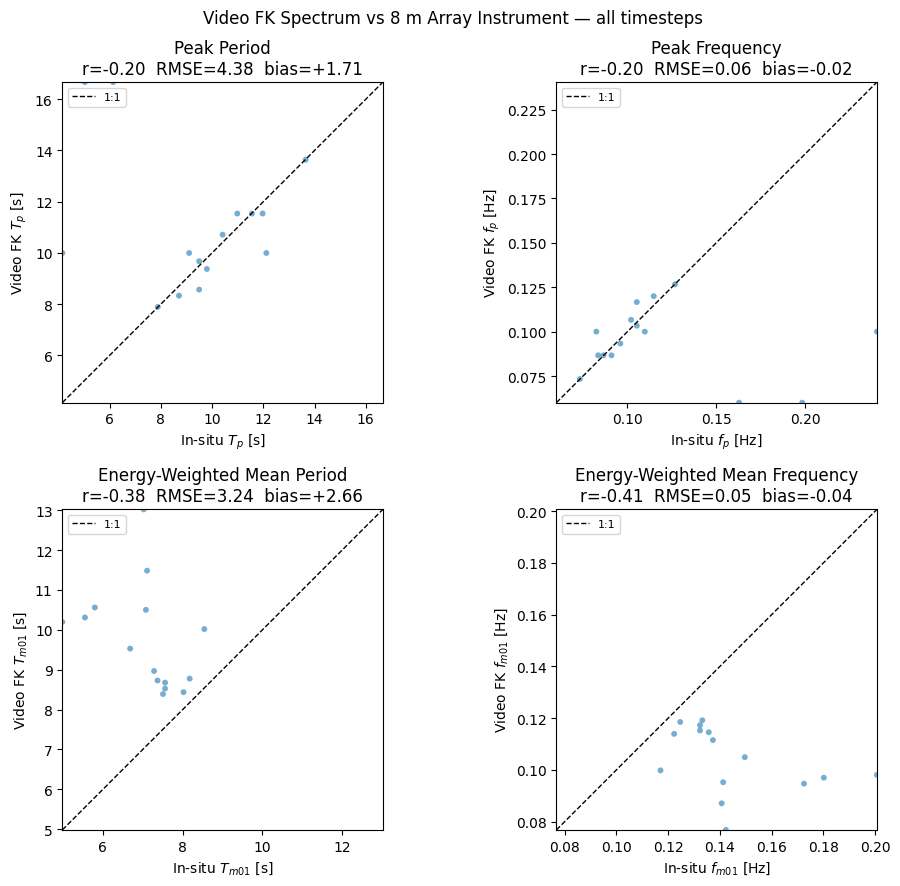

In [28]:
def _scatter_panel(ax, x, y, xlabel, ylabel, title, one_to_one=True):
    """Scatter plot with 1:1 line and skill metrics (r, RMSE, bias)."""
    ax.scatter(x, y, s=18, alpha=0.6, edgecolors='none')
    if one_to_one:
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, 'k--', lw=1, label='1:1')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_aspect('equal')
    r, _   = pearsonr(x, y)
    rmse   = np.sqrt(np.mean((x - y)**2))
    bias   = np.mean(y - x)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nr={r:.2f}  RMSE={rmse:.2f}  bias={bias:+.2f}')
    ax.legend(fontsize=8)

fig, axs = plt.subplots(2, 2, figsize=(10, 9))

_scatter_panel(axs[0, 0], Tp_ins, Tp_vid,
               'In-situ $T_p$ [s]', 'Video FK $T_p$ [s]', 'Peak Period')
_scatter_panel(axs[0, 1], fp_ins, fp_vid,
               'In-situ $f_p$ [Hz]', 'Video FK $f_p$ [Hz]', 'Peak Frequency')
_scatter_panel(axs[1, 0], Tm_ins, Tm_vid,
               'In-situ $T_{m01}$ [s]', 'Video FK $T_{m01}$ [s]', 'Energy-Weighted Mean Period')
_scatter_panel(axs[1, 1], fm_ins, fm_vid,
               'In-situ $f_{m01}$ [Hz]', 'Video FK $f_{m01}$ [Hz]',
               'Energy-Weighted Mean Frequency')

plt.suptitle('Video FK Spectrum vs 8 m Array Instrument — all timesteps', fontsize=12)
plt.tight_layout()


## 9. Outlier Investigation

Rank   Time                    |DTp| [s]  |DTm| [s]   Tp_vid   Tp_ins   Tm_vid   Tm_ins
------------------------------------------------------------------------------------------
1      2021-09-17T17:30:00         11.63       4.76    16.67     5.04    10.31     5.55
2      2021-09-21T12:01:00         10.53       4.76    16.67     6.14    10.56     5.80
3      2021-09-20T19:01:00          5.84       5.21    10.00     4.16    10.20     4.98
4      2021-10-29T11:31:00          0.02       6.00    13.64    13.65    13.02     7.03
5      2021-10-28T12:31:00          2.12       4.38    10.00    12.12    11.48     7.11


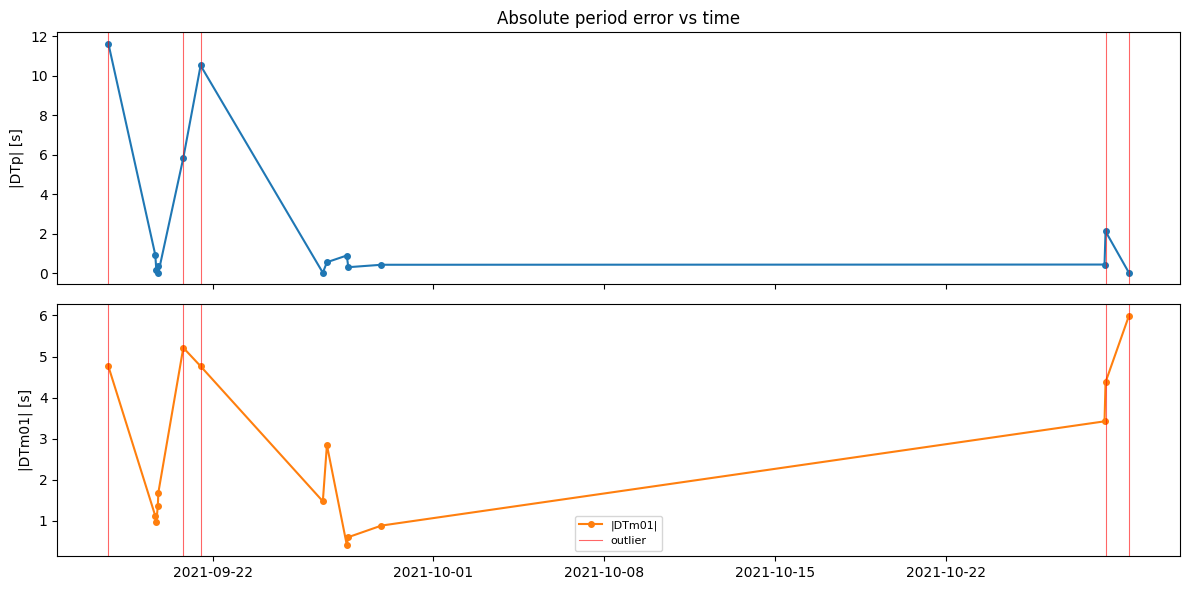

In [29]:
# Rank timesteps by combined absolute error in Tp and Tm.
# Normalise each metric to [0, 1] so both contribute equally to the ranking.
Tp_err = np.abs(Tp_vid - Tp_ins)
Tm_err = np.abs(Tm_vid - Tm_ins)

Tp_err_norm  = Tp_err / Tp_err.max()
Tm_err_norm  = Tm_err / Tm_err.max()
combined_err = Tp_err_norm + Tm_err_norm

N_OUTLIERS  = 5
outlier_idx = np.argsort(combined_err)[::-1][:N_OUTLIERS]

print(f"{'Rank':<6} {'Time':<22} {'|DTp| [s]':>10} {'|DTm| [s]':>10} "
      f"{'Tp_vid':>8} {'Tp_ins':>8} {'Tm_vid':>8} {'Tm_ins':>8}")
print('-' * 90)
for rank, i in enumerate(outlier_idx):
    t_str = str(time_val[i])[:19]
    print(f"{rank+1:<6} {t_str:<22} {Tp_err[i]:>10.2f} {Tm_err[i]:>10.2f} "
          f"{Tp_vid[i]:>8.2f} {Tp_ins[i]:>8.2f} {Tm_vid[i]:>8.2f} {Tm_ins[i]:>8.2f}")

# Time-series of absolute errors with outliers highlighted
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
times_dt = pd.to_datetime(time_val)

axs[0].plot(times_dt, Tp_err, 'o-', ms=4, label='|DTp|')
axs[0].set_ylabel('|DTp| [s]')
axs[0].set_title('Absolute period error vs time')
for i in outlier_idx:
    axs[0].axvline(times_dt[i], color='r', lw=0.8, alpha=0.6)

axs[1].plot(times_dt, Tm_err, 'o-', ms=4, color='C1', label='|DTm01|')
axs[1].set_ylabel('|DTm01| [s]')
for i in outlier_idx:
    axs[1].axvline(times_dt[i], color='r', lw=0.8, alpha=0.6,
                   label='outlier' if i == outlier_idx[0] else '')
axs[1].legend(fontsize=8)
plt.tight_layout()


In [30]:
OUTLIER_VIDEO_DIR = Path('../figures/outlier_videos')
OUTLIER_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

# Additive BGR tint applied to windows that failed QC
QC_TINTS = {
    'missing':   (0,   0,   180),
    'blur':      (0,   120, 120),
    'frozen':    (0,   0,   200),
    'saturated': (180, 0,   0),
}


def _get_qc_tint(qc_tag):
    """Return BGR additive colour for a QC tag string, or None for 'ok'."""
    for key, bgr in QC_TINTS.items():
        if qc_tag.startswith(key):
            return bgr
    return None


def write_outlier_video(rank, ds_idx, result_idx):
    """Write an annotated side-by-side video for one outlier timestep."""
    source   = ds.source.values[ds_idx].replace('_pred', '')
    video_path = os.path.join(ARGUS_PATH, source)
    if not os.path.exists(video_path):
        print(f'  [skip] {video_path}')
        return

    time_str = str(time_val[result_idx])[:19]
    safe_ts  = time_str.replace(':', '').replace(' ', 'T').replace('-', '')
    n_good   = results[result_idx]['n_good']
    qc_tags  = results[result_idx]['qc_log']

    frames = load_frames(video_path)
    _, fs  = get_time_resolution_for_date(
        pd.Timestamp(time_str).to_pydatetime())

    # Extract each analysis window as a crop
    window_crops = [frames[:, r0:r0+TILE, c0:c0+TILE] for r0, c0 in WINDOWS]
    del frames
    gc.collect()

    n_windows = len(window_crops)
    W_out, H_out = TILE * n_windows, TILE
    out_path = str(OUTLIER_VIDEO_DIR / f'outlier_{rank:02d}_{safe_ts}.mp4')
    writer   = cv2.VideoWriter(
        out_path, cv2.VideoWriter_fourcc(*'avc1'), float(fs), (W_out, H_out))

    for frame_idx in range(window_crops[0].shape[0]):
        tiles = []
        for win_idx, crop in enumerate(window_crops):
            gray = np.clip(crop[frame_idx], 0, 255).astype(np.uint8)
            bgr  = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR).astype(np.int16)
            tint = _get_qc_tint(qc_tags[win_idx])
            if tint is not None:
                bgr[:, :, 0] = np.clip(bgr[:, :, 0] + tint[0], 0, 255)
                bgr[:, :, 1] = np.clip(bgr[:, :, 1] + tint[1], 0, 255)
                bgr[:, :, 2] = np.clip(bgr[:, :, 2] + tint[2], 0, 255)
            tiles.append(bgr.astype(np.uint8))

        frame_out = np.concatenate(tiles, axis=1)

        # Annotate the first frame with period values and QC legend
        if frame_idx == 0:
            Tp_v, Tp_i = Tp_vid[result_idx], Tp_ins[result_idx]
            Tm_v, Tm_i = Tm_vid[result_idx], Tm_ins[result_idx]
            label = (f'Rank {rank}  {time_str[:16]}  n_good={n_good}/{n_windows}'
                     f'  Tp {Tp_v:.1f}/{Tp_i:.1f}s  Tm {Tm_v:.1f}/{Tm_i:.1f}s')
            cv2.putText(frame_out, label, (4, 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1, cv2.LINE_AA)
            legend = 'yellow=missing  orange=blur  red=frozen  blue=sat'
            cv2.putText(frame_out, legend, (4, H_out - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.25, (180, 180, 180), 1, cv2.LINE_AA)

        t_label = f't={frame_idx/fs:.1f}s'
        cv2.putText(frame_out, t_label, (W_out - 60, H_out - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (200, 200, 200), 1, cv2.LINE_AA)
        writer.write(frame_out)

    writer.release()
    del window_crops
    gc.collect()
    print(f'  saved -> {out_path}')


print('Generating outlier videos ...')
for rank, result_idx in enumerate(outlier_idx, start=1):
    ds_idx   = int(valid_arr[result_idx])
    time_str = str(time_val[result_idx])[:19]
    print(f'\nRank {rank}: {time_str}  '
          f'|DTp|={Tp_err[result_idx]:.2f}s  |DTm|={Tm_err[result_idx]:.2f}s')
    write_outlier_video(rank, ds_idx, result_idx)
print('\nDone.')


Generating outlier videos ...

Rank 1: 2021-09-17T17:30:00  |DTp|=11.63s  |DTm|=4.76s
1.9192gb allocated
  saved -> ../figures/outlier_videos/outlier_01_20210917T173000.mp4

Rank 2: 2021-09-21T12:01:00  |DTp|=10.53s  |DTm|=4.76s
1.9192gb allocated
  saved -> ../figures/outlier_videos/outlier_02_20210921T120100.mp4

Rank 3: 2021-09-20T19:01:00  |DTp|=5.84s  |DTm|=5.21s
1.4976gb allocated
  saved -> ../figures/outlier_videos/outlier_03_20210920T190100.mp4

Rank 4: 2021-10-29T11:31:00  |DTp|=0.02s  |DTm|=6.00s
1.9192gb allocated
  saved -> ../figures/outlier_videos/outlier_04_20211029T113100.mp4

Rank 5: 2021-10-28T12:31:00  |DTp|=2.12s  |DTm|=4.38s
2.204gb allocated
  saved -> ../figures/outlier_videos/outlier_05_20211028T123100.mp4

Done.


In [33]:
def save_outlier_fk_plots(rank, ds_idx, result_idx, out_dir):
    """
    Recompute the full F-K spectrum for one outlier timestep and save
    two diagnostic figures:
      1. Normalised 1-D spectrum comparison (video vs instrument)
      2. Instrument directional spectrum (polar plot)
    """
    source   = ds.source.values[ds_idx].replace('_pred', '')
    in_path  = os.path.join(ARGUS_PATH, source)
    time_str = str(time_val[result_idx])[:19]
    safe_ts  = time_str.replace(':', '').replace(' ', 'T').replace('-', '')
    fig_prefix = out_dir / f'outlier_{rank:02d}_{safe_ts}'
    print(f'  FK plots rank {rank}: {time_str}')

    frames = load_frames(in_path)
    _, fs  = get_time_resolution_for_date(
        pd.Timestamp(time_str).to_pydatetime())

    # Collect spectra from good windows (same QC flags as the main analysis)
    window_spectra     = []
    window_kbin_counts = []
    qc_tags = results[result_idx]['qc_log']

    for win_idx, (r0, c0) in enumerate(WINDOWS):
        if not qc_tags[win_idx].startswith('ok'):
            continue
        crop = frames[:, r0:r0+TILE, c0:c0+TILE].copy()
        f_pos, _, Ef_norm_k, n_k = compute_dispersion_filtered_spectrum(
            crop, fs, dx, nperseg, d_min, d_max, thickness)
        window_spectra.append(Ef_norm_k)
        window_kbin_counts.append(n_k)
        del crop
        gc.collect()

    del frames
    gc.collect()

    Ef_nk_mean = np.mean(window_spectra, axis=0)
    n_k_mean  = np.mean(window_kbin_counts, axis=0)
    analysis_freq_mask   = (f_pos >= 1/30) & (f_pos <= 1.0)

    # Peak frequency
    peak_indices, peak_props = find_peaks(
        Ef_nk_mean[analysis_freq_mask], prominence=0)
    if len(peak_indices) > 0:
        dominant_peak_idx = peak_indices[np.argmax(peak_props['prominences'])]
        fp_filt = float(f_pos[analysis_freq_mask][dominant_peak_idx])
    else:
        dominant_peak_idx = int(np.argmax(Ef_nk_mean[analysis_freq_mask]))
        fp_filt = float(f_pos[analysis_freq_mask][dominant_peak_idx])

    Tp_i = Tp_ins[result_idx]
    Tm_v, Tm_i = Tm_vid[result_idx], Tm_ins[result_idx]
    n_good     = results[result_idx]['n_good']

    # ── Figure 1: normalised 1-D spectrum comparison ──────────────────────────
    insitu_spectrum = ds.waveEnergyDensity.values[ds_idx]
    energy_normalized = Ef_nk_mean / Ef_nk_mean[analysis_freq_mask].max()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.loglog(f_pos[analysis_freq_mask], energy_normalized[analysis_freq_mask],
              label=f'FK spectrum (video, {n_good}/{len(WINDOWS)} windows)', alpha=0.85)
    ax.loglog(ds.waveFrequency.values, insitu_spectrum / insitu_spectrum.max(),
              label='8 m array (instrument)', color='C1', alpha=0.85)
    ax.axvline(fp_filt,       color='C0', ls='--', lw=1.5,
               label=f'$T_p$ video = {1/fp_filt:.1f} s')
    ax.axvline(1/Tp_i,             color='C1', ls='--', lw=1.5,
               label=f'$T_p$ insitu = {Tp_i:.1f} s')
    ax.axvline(fm_vid[result_idx], color='C0', ls=':',  lw=1.2,
               label=f'$f_m$ video = {Tm_v:.1f} s')
    ax.axvline(fm_ins[result_idx], color='C1', ls=':',  lw=1.2,
               label=f'$f_m$ insitu = {Tm_i:.1f} s')
    # Shade frequencies excluded from Tm01 by the n_k_min threshold
    excluded_freqs = analysis_freq_mask & (n_k_mean < N_K_MIN)
    if excluded_freqs.any():
        ax.axvspan(f_pos[analysis_freq_mask][0], f_pos[excluded_freqs][-1],
                   alpha=0.08, color='grey',
                   label=f'n_k < {N_K_MIN} (excluded from Tm01)')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Normalised PSD')
    ax.set_xlim(1/30, 1.0)
    ax.legend(fontsize=7)
    ax.set_title(f'Outlier rank {rank} — {time_str[:16]}\n'
                 f'|DTp|={Tp_err[result_idx]:.2f} s  |DTm|={Tm_err[result_idx]:.2f} s')
    plt.tight_layout()
    fig.savefig(str(fig_prefix) + '_1d_spectrum.png', dpi=150)
    plt.close(fig)

    # ── Figure 2: instrument directional spectrum ─────────────────────────────
    spec_cmap = plt.cm.inferno.copy()
    spec_cmap.set_under('lightgrey')
    dirs_rad    = np.radians(ds.waveDirectionBins.values)
    insitu_freqs = ds.waveFrequency.values
    dir_spec    = ds.directionalWaveEnergyDensity.values[ds_idx]
    dirs_rad_closed = np.append(dirs_rad, dirs_rad[0] + 2*np.pi)
    dir_spec_closed = np.concatenate([dir_spec, dir_spec[:, :1]], axis=1)
    TH_inst, FR_inst = np.meshgrid(dirs_rad_closed, insitu_freqs)

    peak_dir_insitu = float(ds.wavePeakDirectionPeakFrequency.values[ds_idx])
    mean_dir_insitu = float(ds.waveMeanDirectionPeakFrequency.values[ds_idx])
    peak_freq_insitu = 1.0 / float(ds.waveTp.values[ds_idx])

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
    ax.set_theta_direction(-1); ax.set_theta_zero_location('N')
    im = ax.contourf(TH_inst, FR_inst,
                     np.log10(np.maximum(dir_spec_closed, 1e-10)),
                     cmap=spec_cmap, levels=np.linspace(-4, -1.2, 14))
    plt.colorbar(im, ax=ax, label='log$_{10}$ E [m$^2$/Hz/°]')
    ax.scatter(np.radians(peak_dir_insitu), peak_freq_insitu,
               color='cyan', s=80, zorder=5, label='Peak dir')
    ax.scatter(np.radians(mean_dir_insitu), peak_freq_insitu,
               color='blue', s=80, zorder=5, marker='^', label='Mean dir')
    ax.legend(loc='lower left', fontsize=8)
    ax.set_ylim(0, 0.5)
    ax.set_title(f'8 m Array — Outlier rank {rank}\n{time_str[:16]}\n'
                 f'$T_p$={1/peak_freq_insitu:.1f} s  $T_m$={Tm_i:.1f} s')
    plt.tight_layout()
    fig.savefig(str(fig_prefix) + '_directional.png', dpi=150)
    plt.close(fig)

    print(f'    saved {fig_prefix.name}_*.png')


print('Generating outlier F-K diagnostic plots ...')
for rank, result_idx in enumerate(outlier_idx, start=1):
    ds_idx = int(valid_arr[result_idx])
    save_outlier_fk_plots(rank, ds_idx, result_idx, OUTLIER_VIDEO_DIR)
print('Done.')


Generating outlier F-K diagnostic plots ...
  FK plots rank 1: 2021-09-17T17:30:00
1.9192gb allocated
    saved outlier_01_20210917T173000_*.png
  FK plots rank 2: 2021-09-21T12:01:00
1.9192gb allocated
    saved outlier_02_20210921T120100_*.png
  FK plots rank 3: 2021-09-20T19:01:00
1.4976gb allocated
    saved outlier_03_20210920T190100_*.png
  FK plots rank 4: 2021-10-29T11:31:00
1.9192gb allocated
    saved outlier_04_20211029T113100_*.png
  FK plots rank 5: 2021-10-28T12:31:00
2.204gb allocated
    saved outlier_05_20211028T123100_*.png
Done.
